In [22]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("../plots.mplstyle")
from pathlib import Path
import re

In [31]:

def load_spectrum_txt(file_path, delimiter=","):
    data = np.loadtxt(file_path, delimiter=delimiter)

    wavelength_nm = data[:, 0]
    intensity_arb = data[:, 1]

    return wavelength_nm, intensity_arb


def plot_spectrum(ax, wavelength_nm, intensity, integration_time, color="blue", label=""):
    ax.plot(wavelength_nm, intensity / (integration_time), color=color, label=label, alpha=0.7)

    ax.set_xlabel("wavelength [nm]")

    ax.grid(True, alpha=0.3)

    return ax

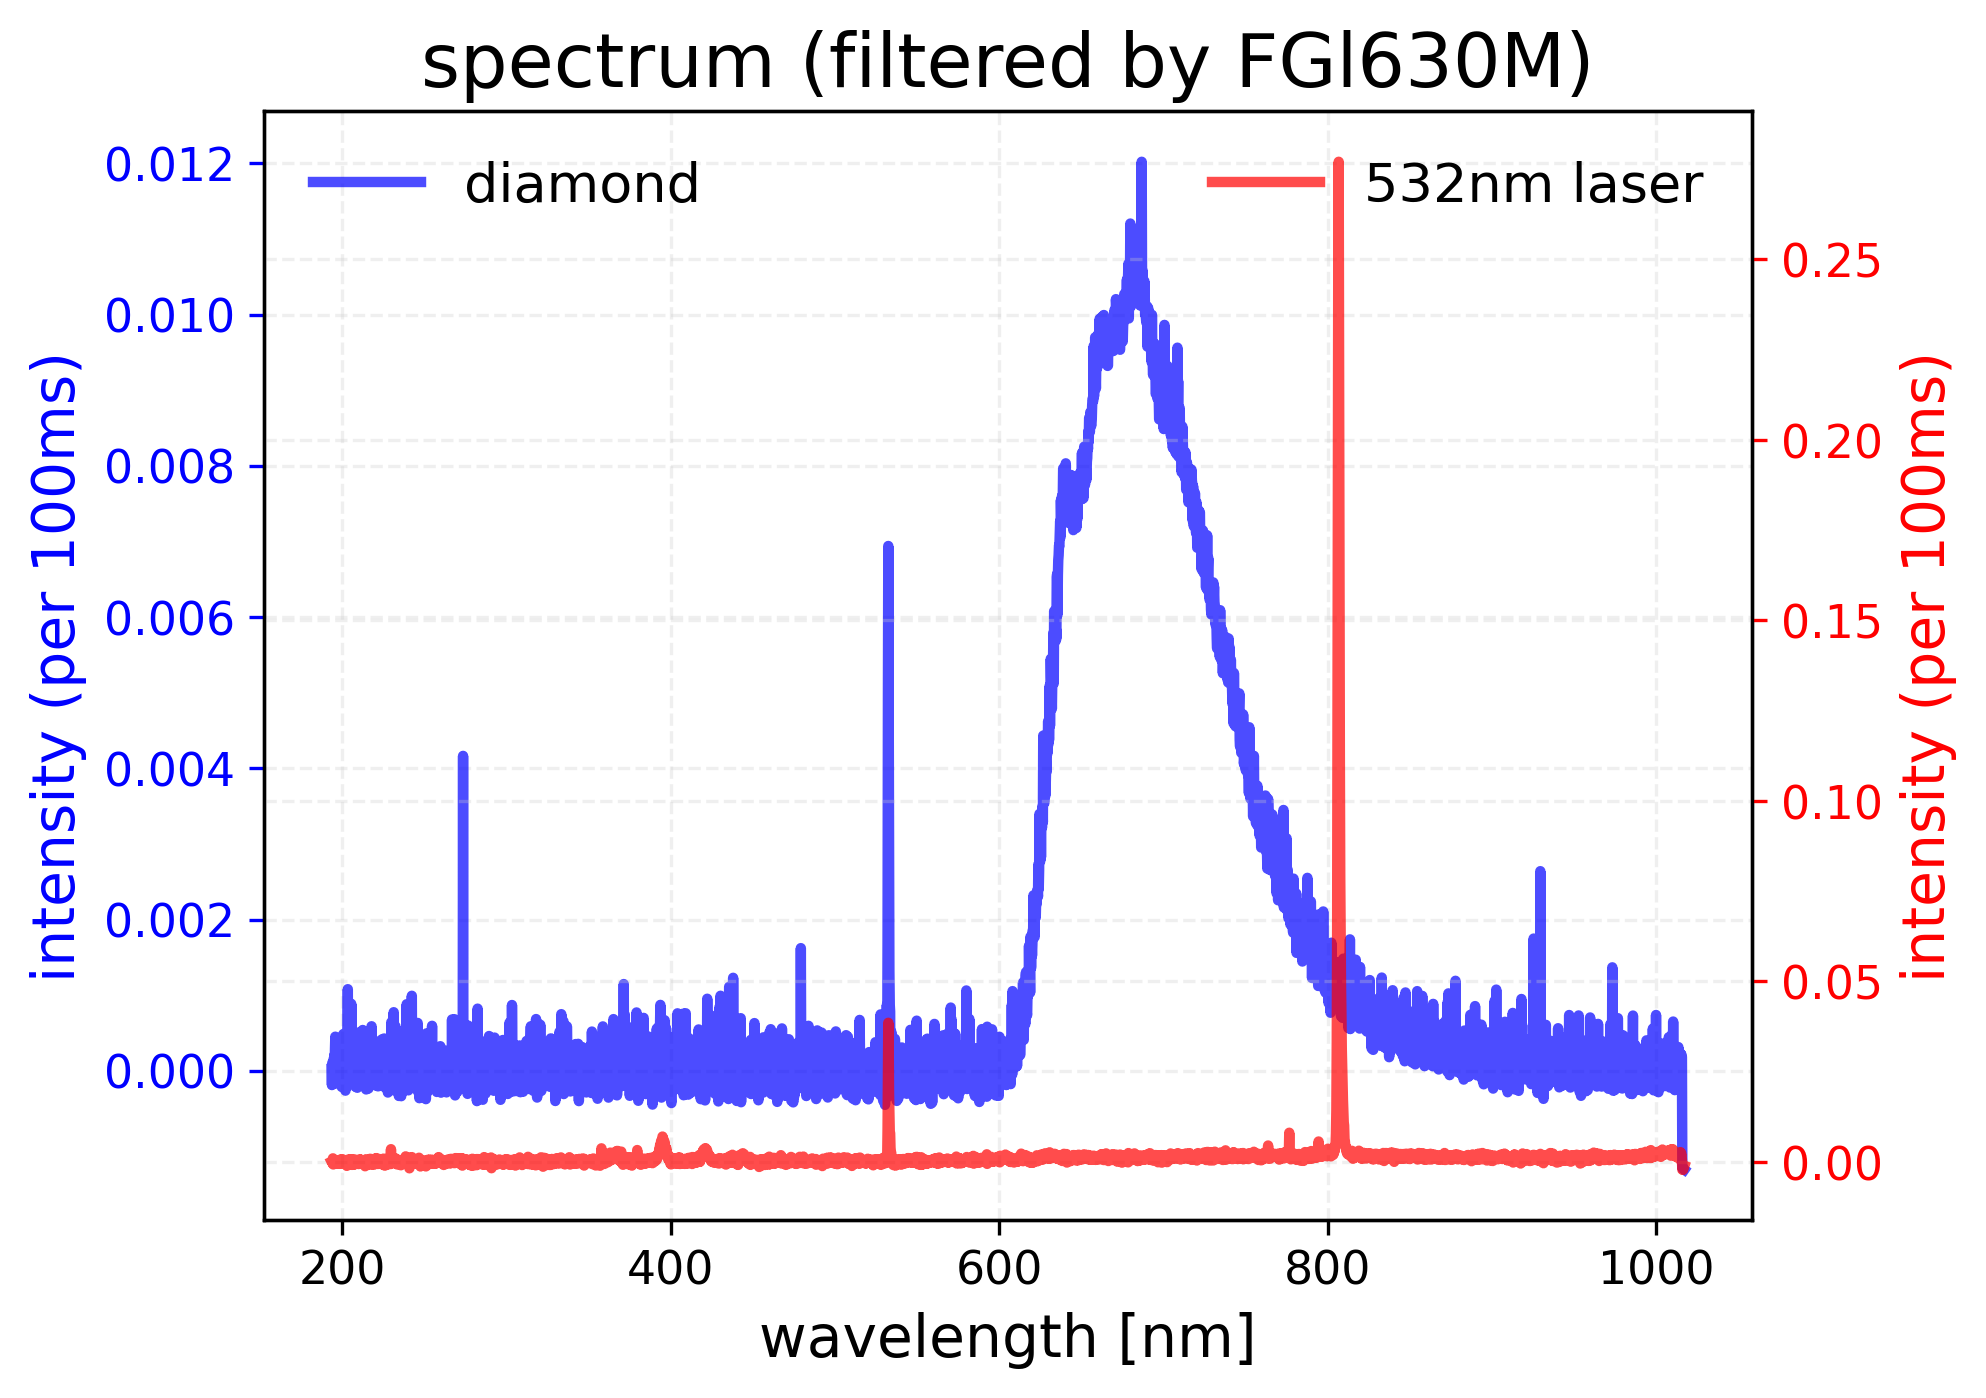

In [21]:

folder = Path("./8000ms")
fig, ax = plt.subplots(dpi=300)
total_wavelength = []
total_intensity = []

for file in folder.iterdir():
    matches = re.findall("nv_([0-9]+)_FGl630M", str(file))
    if matches:
        wl, intensity = load_spectrum_txt(file)
        total_wavelength.append(wl)
        total_intensity.append(intensity)
        
average_wl = np.average(np.array(total_wavelength), axis=0)
average_intensity = np.average(np.array(total_intensity), axis=0)
ax = plot_spectrum(ax, average_wl, average_intensity, 8000e-3, label="diamond")

ax.set_ylabel("intensity (per 100ms)", color="blue")
ax.tick_params(axis="y", labelcolor="blue", colors="blue")

ax.set_title("spectrum (filtered by FGl630M)")
plt.legend(loc="upper left")

ax2 = ax.twinx()
wl, intensity = load_spectrum_txt("./filters/laser_FGl630M.txt")
ax2 = plot_spectrum(ax2, wl, intensity, 250e-3, color="red", label="532nm laser")
ax2.set_ylabel("intensity (per 100ms)", color="red")
ax2.tick_params(axis="y", labelcolor="red", colors="red")



plt.legend(loc="upper right")
plt.show()

C:\Users\codin\AppData\Local\Temp\ipykernel_21028\2074990769.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


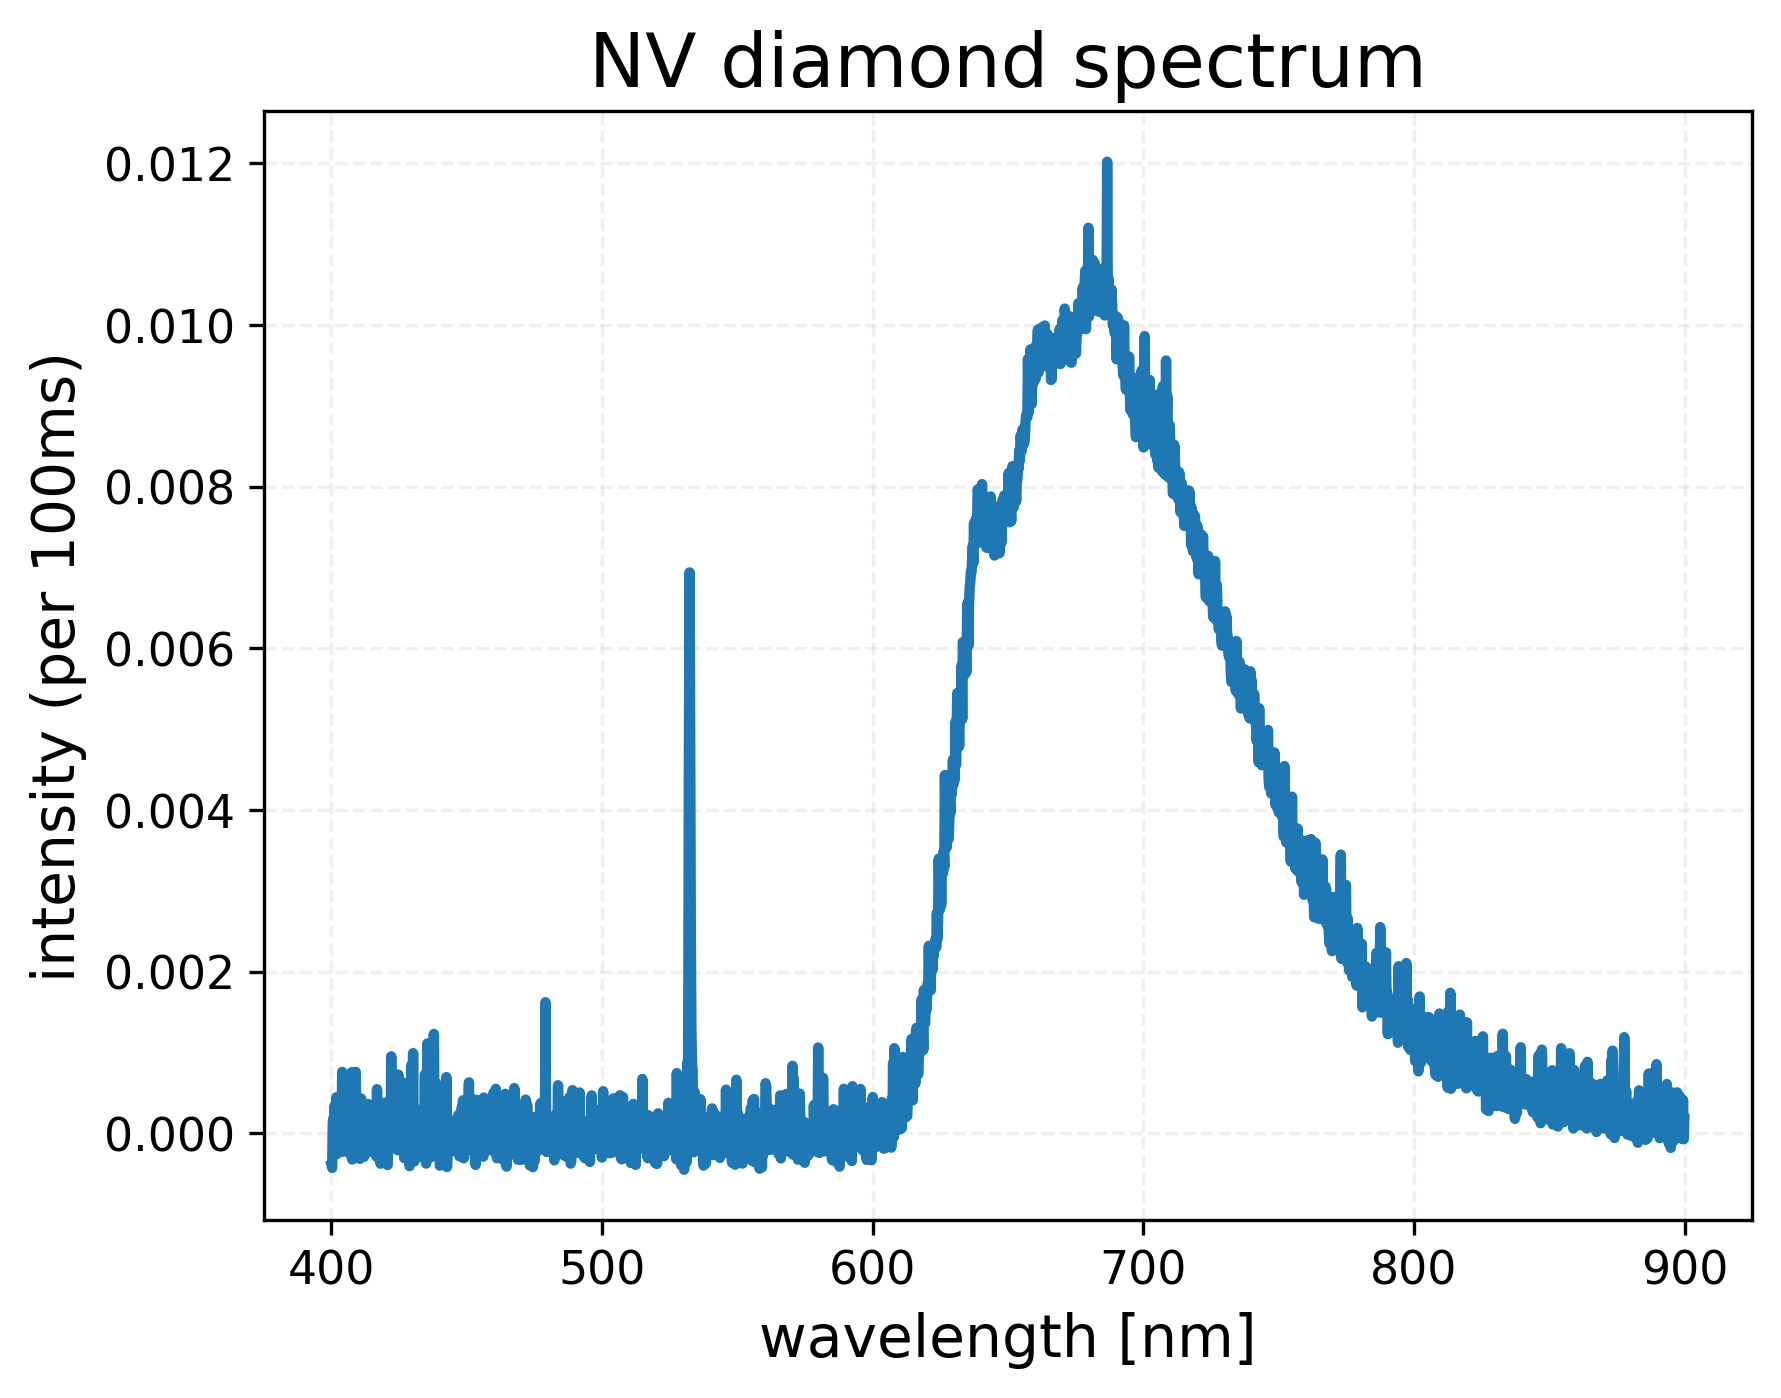

In [56]:
fig, ax = plt.subplots(dpi=300)
mask = np.bitwise_and(average_wl > 400, average_wl < 900)
ax = plot_spectrum(ax, average_wl[mask], average_intensity[mask], 8000e-3)
ax.set_title("NV diamond spectrum")

plt.legend()
plt.show()

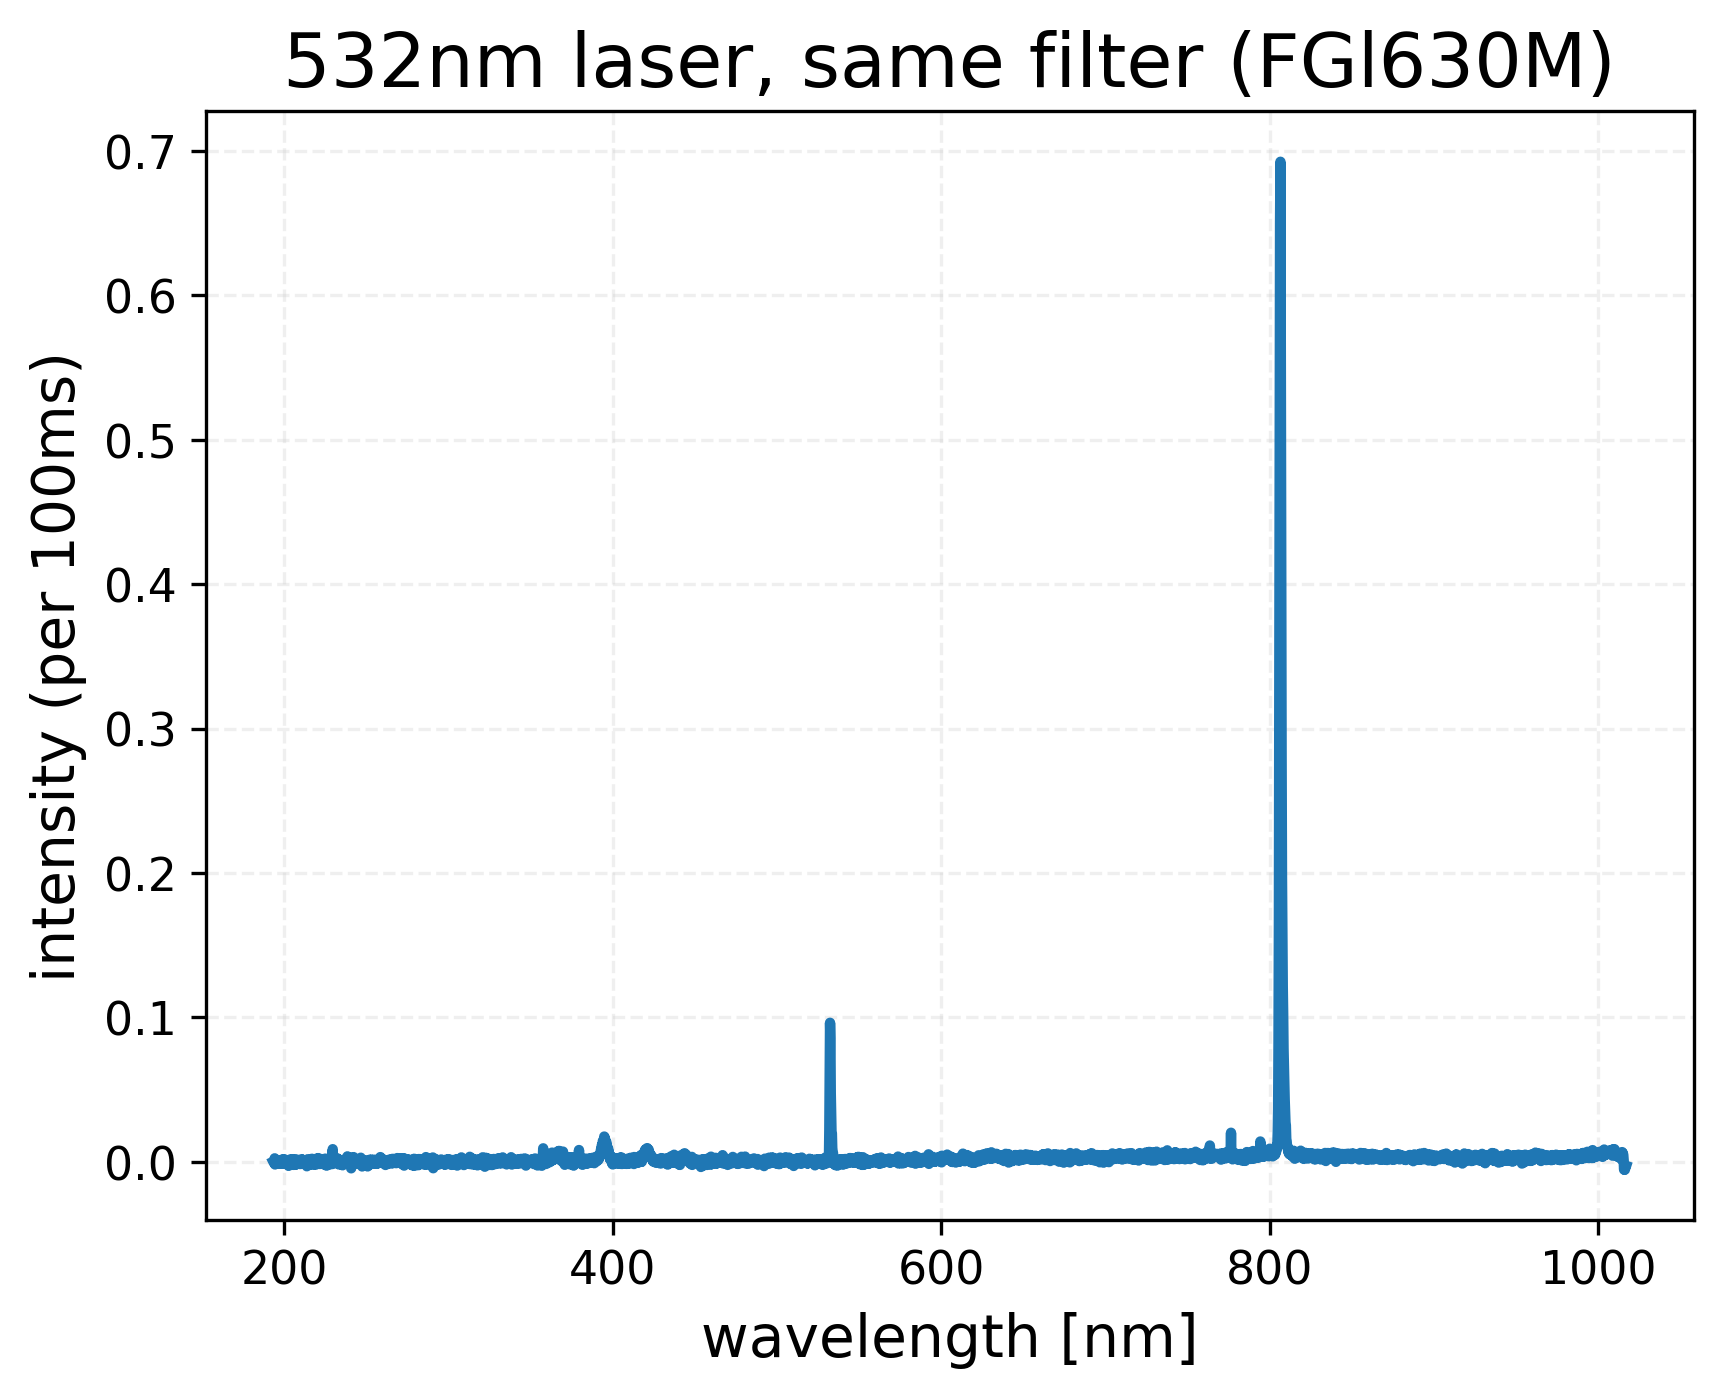

In [62]:
wl, intensity = load_spectrum_txt("./filters/laser_FGl630M.txt")
fig, ax = plt.subplots(dpi=300)
ax = plot_spectrum(ax, wl, intensity, 100e-3)
ax.set_title("532nm laser, same filter (FGl630M)")
plt.show()

# weaker in the diamond spectrum measurement because it also goes through the dichroic

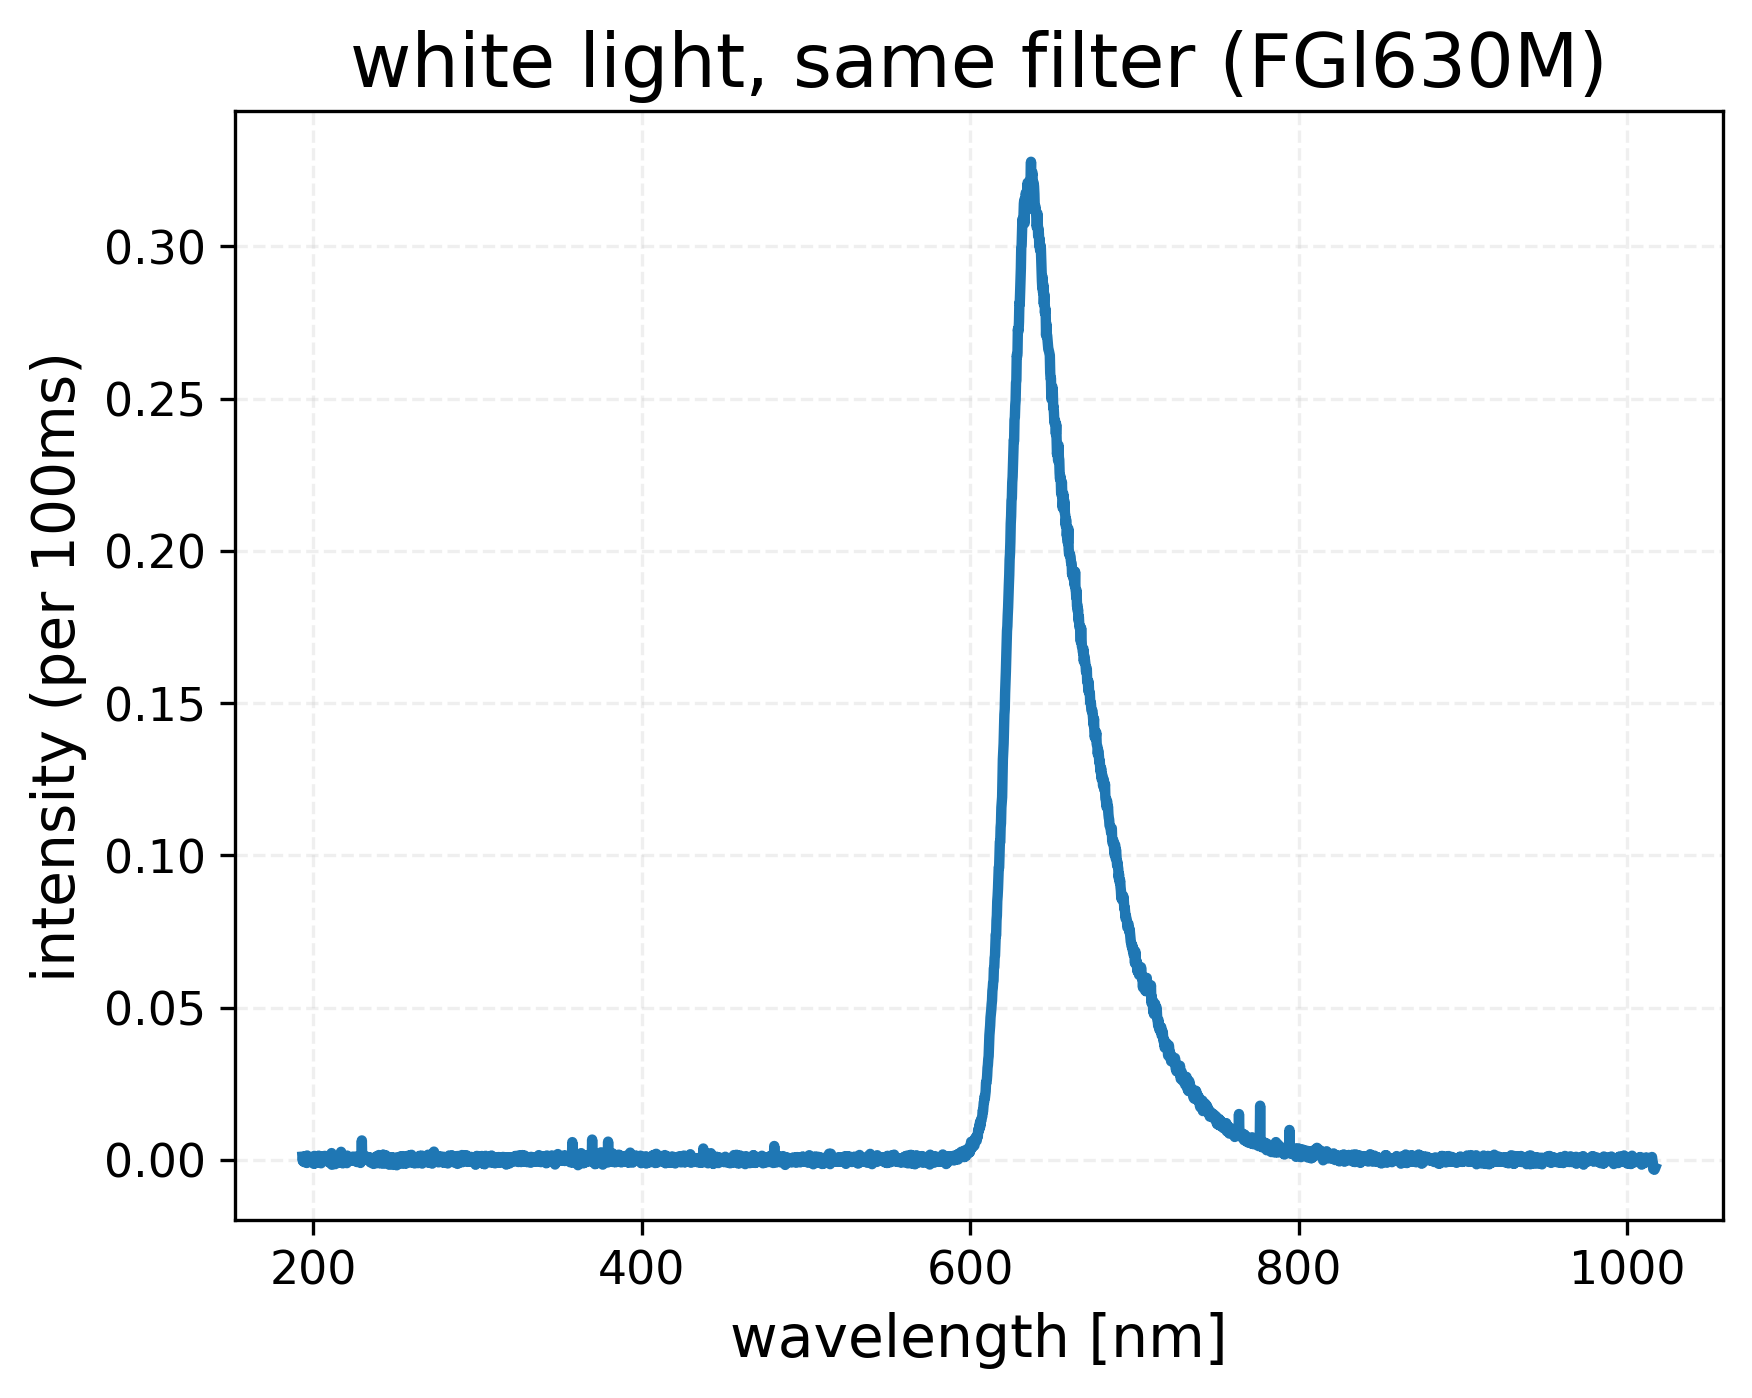

In [60]:
wl, intensity = load_spectrum_txt("./filters/white_light_FGl630M.txt")
fig, ax = plt.subplots(dpi=300)
ax = plot_spectrum(ax, wl, intensity, 250e-3)
ax.set_title("white light, same filter (FGl630M)")
plt.show()

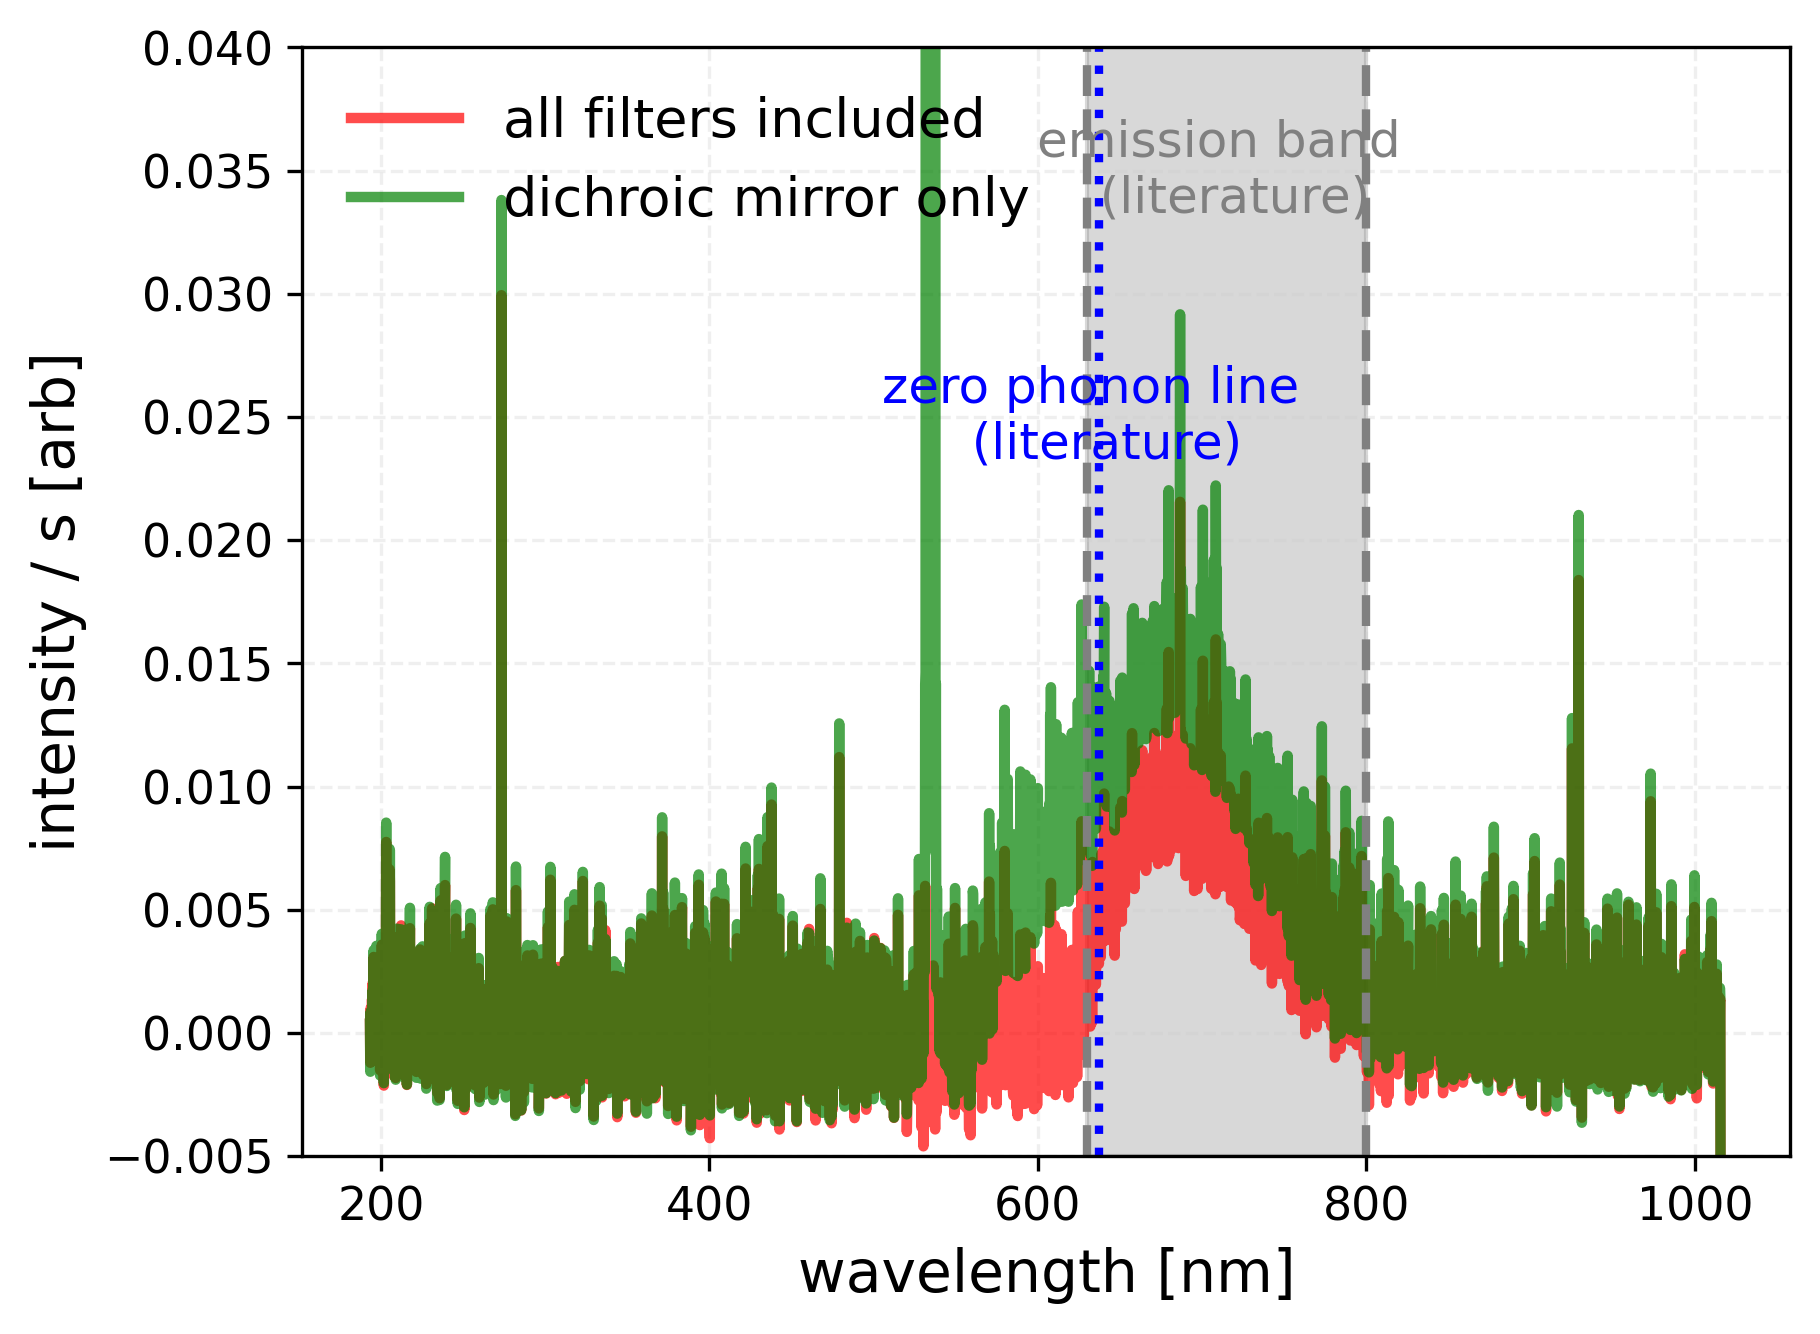

In [68]:

# wl, intensity = load_spectrum_txt("./combined_filters/setup_fgla630_fesh080_fgl630_background.txt")
wl_1, intensity_1 = load_spectrum_txt("./combined_filters/setup_fgl630_fesh080_fgl630.txt")
wl_2, intensity_2 = load_spectrum_txt("./combined_filters/setup_no_fesh0800_3.txt")

fig, ax = plt.subplots(dpi=300)
# ax = plot_spectrum(ax, wl, intensity, 250e-3)
ax = plot_spectrum(ax, wl_1, intensity_1, 10, color="red", label="all filters included")
ax = plot_spectrum(ax, wl_2, intensity_2, 10, color="green", label="dichroic mirror only")
# ax = plot_spectrum(ax, average_wl, average_intensity / 10, 8000e-3, label="diamond")

ax.set_ylabel("intensity / s [arb]")
ax.set_ylim([-0.005, 0.04])
ax.axvspan(630, 800, color="gray", alpha=0.3)
ax.text(
    (630 + 800) / 2,
    0.035,
    "emission band \n (literature)",
    ha="center",
    va="center",
    fontsize=12,
    color="gray"
)
ax.axvline(630, color="gray", linestyle="--", linewidth=2)
ax.axvline(800, color="gray", linestyle="--", linewidth=2)

ax.axvline(637, color="blue", linestyle=":", linewidth=2)
ax.text(
    637,
    0.025,
    "zero phonon line \n (literature)",
    ha="center",
    va="center",
    fontsize=12,
    color="blue"
)


plt.legend()
plt.show()

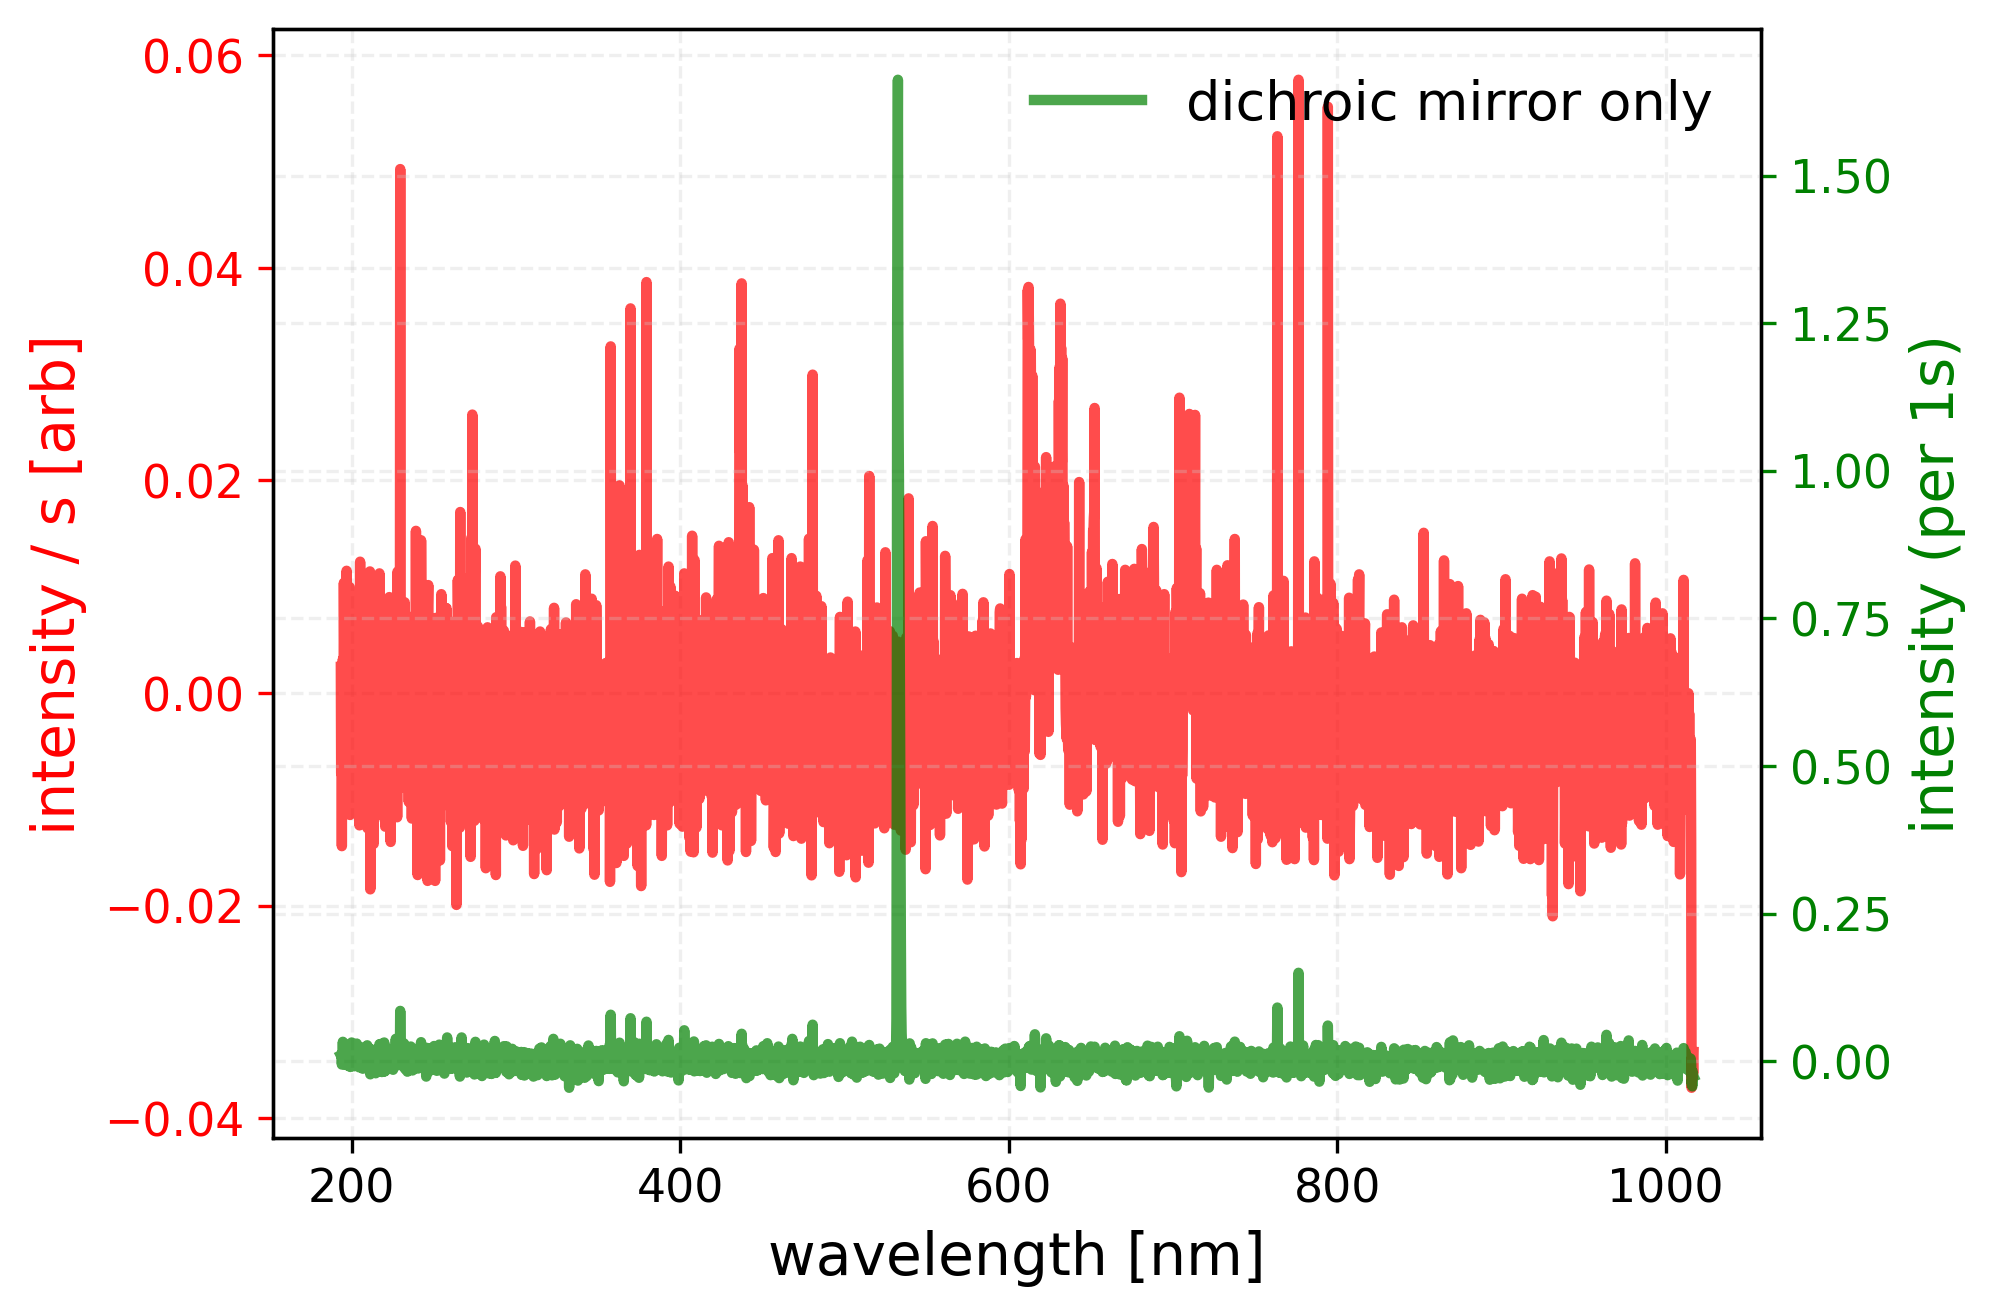

In [70]:

# wl, intensity = load_spectrum_txt("./combined_filters/setup_fgla630_fesh080_fgl630_background.txt")
wl_1, intensity_1 = load_spectrum_txt("./filters/laser_FGl630M_shortpass.txt")
wl_2, intensity_2 = load_spectrum_txt("./filters/darkroom_laser_DMLP550.txt")

fig, ax = plt.subplots(dpi=300)
# ax = plot_spectrum(ax, wl, intensity, 250e-3)
ax = plot_spectrum(ax, wl_1, intensity_1, 1000e-3, color="red", label="bandpass only")
# ax = plot_spectrum(ax, wl_2, intensity_2 + 0, 100e-3, color="green", label="dichroic mirror only")


ax.set_ylabel("intensity / s [arb]", color="red")
ax.tick_params(axis="y", labelcolor="red", colors="red")


ax2 = ax.twinx()
ax2 = plot_spectrum(ax2, wl_2, intensity_2, 100e-3, color="green", label="dichroic mirror only")
ax2.set_ylabel("intensity (per 1s)", color="green")
ax2.tick_params(axis="y", labelcolor="green", colors="green")


ax.set_ylabel("intensity / s [arb]")

# ax.set_title("white light, same filter (FGl630M)")
plt.legend()
plt.show()

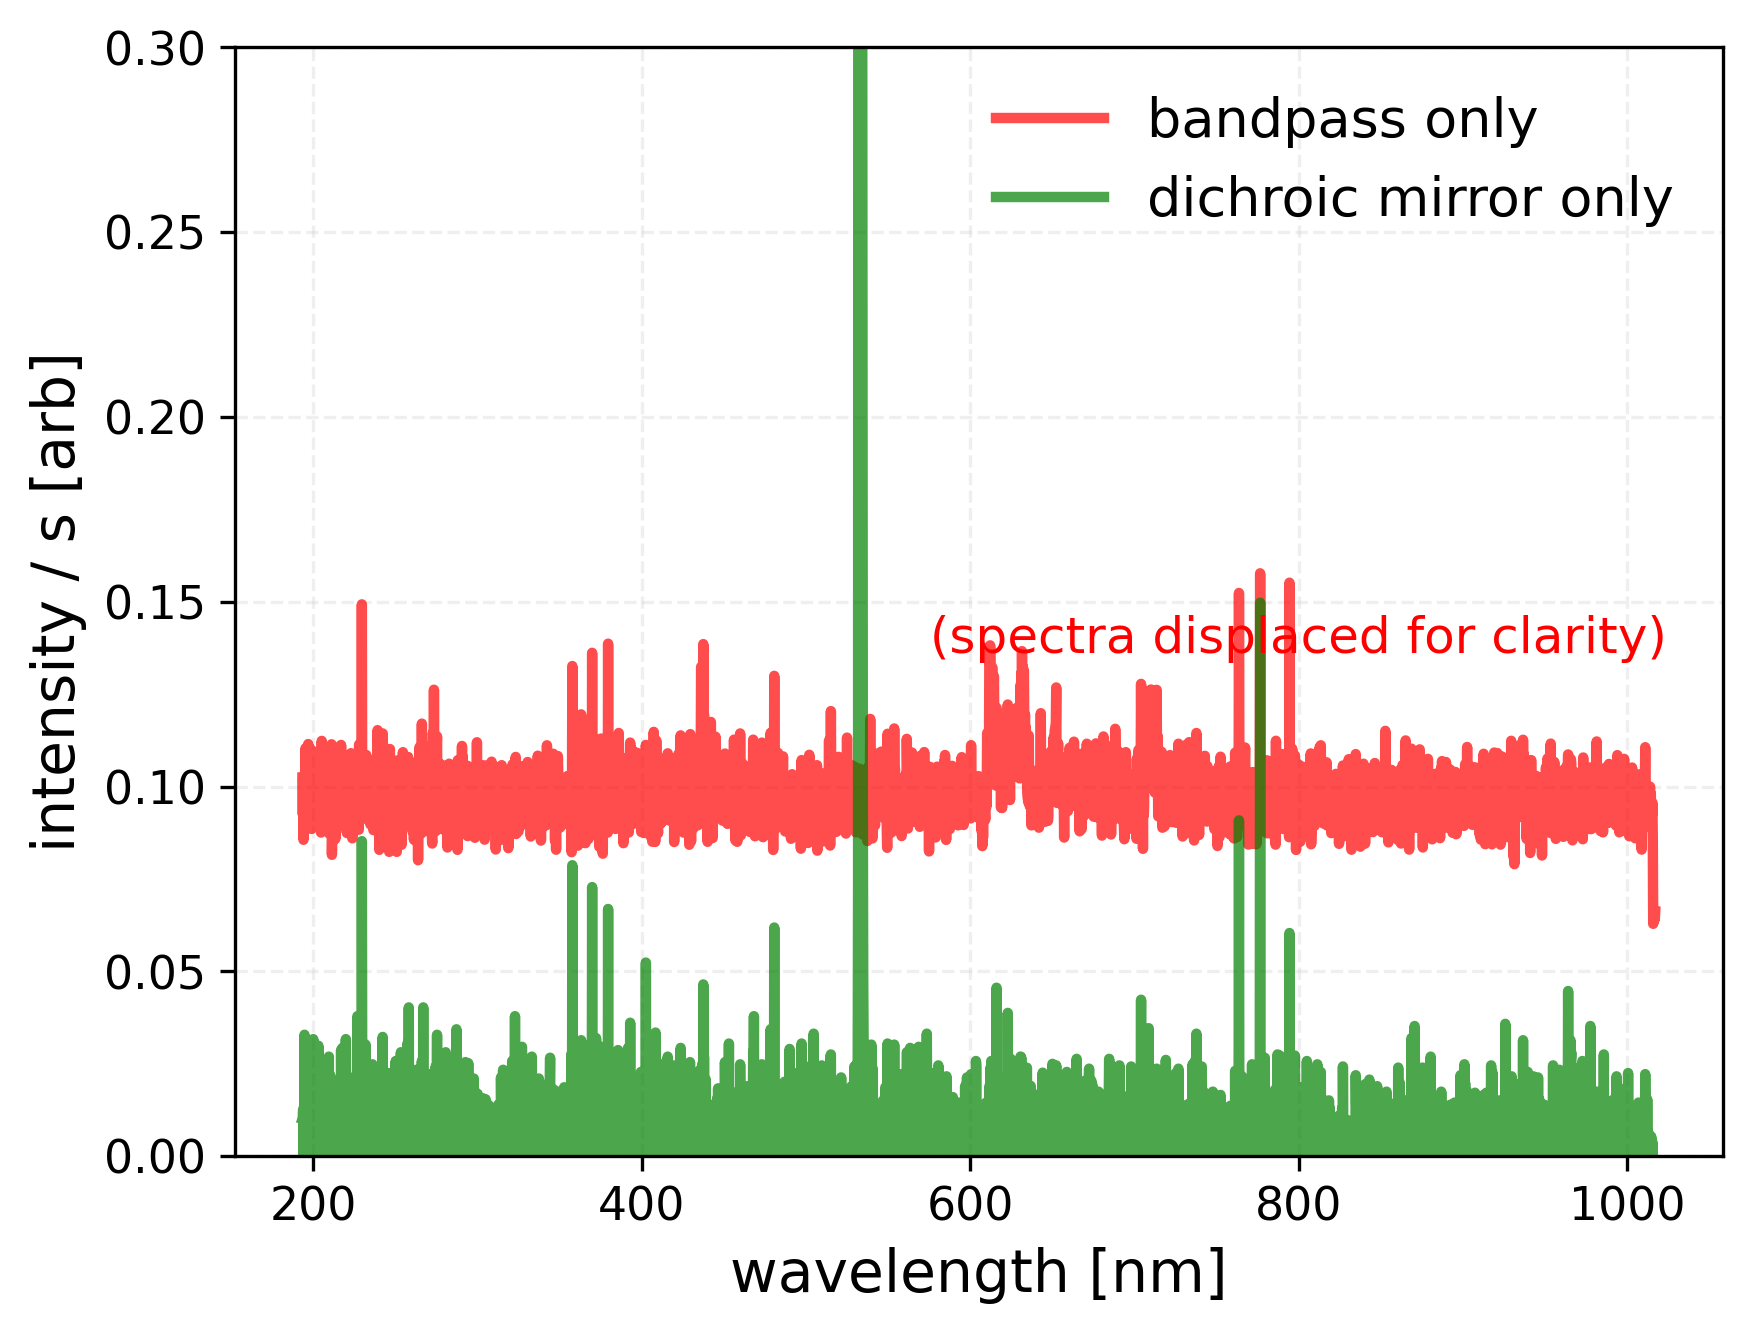

: 

In [ ]:
wl_1, intensity_1 = load_spectrum_txt("./filters/laser_FGl630M_shortpass.txt")
wl_2, intensity_2 = load_spectrum_txt("./filters/darkroom_laser_DMLP550.txt")

fig, ax = plt.subplots(dpi=300)
# ax = plot_spectrum(ax, wl, intensity, 250e-3)
ax = plot_spectrum(ax, wl_1, intensity_1 + 0.1, 1000e-3, color="red", label="bandpass only")
ax = plot_spectrum(ax, wl_2, intensity_2, 100e-3, color="green", label="dichroic mirror only")


ax.set_ylabel("intensity / s [arb]")
ax.text(
    800,
    0.1 + 0.04,
    "(spectra displaced for clarity)",
    ha="center",
    va="center",
    fontsize=12,
    color="red"
)
ax.set_ylim([0, 0.3])

plt.legend()
plt.show()